# Notebook 04: Comparative Analysis
This focuses on loading our best models from MLP and RNN variants for a final test comparison.

In [1]:
import sys
import time
import pickle
import glob
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch.nn as nn

sys.path.insert(0, '../src')
from preprocess import DataManager, DataConfig, MAX_VOCAB_SIZE, MAX_LEN, BATCH_SIZE
from mlp_model import MLPClassifier
from rnn_model import RNNClassifier

sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using Device: {device}")

# Load test data via DataManager
config = DataConfig(
    max_vocab_size=MAX_VOCAB_SIZE,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
    test_size=0.20,
    val_size=0.10,
    random_state=42
)

manager = DataManager(config)
train_loader, val_loader, test_loader, vocab_builder = manager.prepare()
vocab_size = len(vocab_builder)
print(f"✓ Formulated Test Dataloader: {len(test_loader)} batches")


d:\JupyterEnvs\my_new_kernel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Using Device: cpu
DATA PREPARATION PIPELINE
Loading IMDb dataset...
  Loaded 50,000 samples
Preprocessing texts...
  Cleaned 50,000 texts
Building vocabulary...
  Vocabulary size: 20,000
Creating DataLoaders...
  Train batches: 563
  Val batches: 63
  Test batches: 157
✓ Formulated Test Dataloader: 157 batches


In [2]:
# Retrieve MLP Best Config
try:
    with open('../results/ablation_results.pkl', 'rb') as f:
        ablation = pickle.load(f)
        
    depth_cfg = ablation['best_depth_config']
    embed_dim = ablation['best_embed_dim']
    dropout = ablation.get('best_dropout', 0.3)
    
    mlp_model = MLPClassifier(vocab_size=vocab_size, embedding_dim=embed_dim, hidden_dims=depth_cfg['hidden_dims'], dropout=dropout).to(device)
    mlp_model.load_state_dict(torch.load(f"../checkpoints/mlp_dropout{str(dropout).replace('.','')}.pt", map_location=device))
    print("✓ MLP Loaded correctly.")
except Exception as e:
    print("Fallback to direct parsing for MLP", e)
    mlp_model = MLPClassifier(vocab_size=vocab_size, embedding_dim=128, hidden_dims=[128, 256, 128], dropout=0.3).to(device)
    import glob
    for pt in glob.glob('../checkpoints/mlp_*.pt'):
        try:
            mlp_model.load_state_dict(torch.load(pt, map_location=device))
            print("Loaded", pt)
            break
        except:
            pass

# Initialize RNN Models
rnn_model = RNNClassifier(vocab_size=vocab_size, embedding_dim=128, hidden_dim=128, n_layers=1, rnn_type='rnn', bidirectional=True, dropout=0.3).to(device)
lstm_model = RNNClassifier(vocab_size=vocab_size, embedding_dim=128, hidden_dim=128, n_layers=2, rnn_type='lstm', bidirectional=True, dropout=0.3).to(device)
gru_model = RNNClassifier(vocab_size=vocab_size, embedding_dim=128, hidden_dim=128, n_layers=1, rnn_type='gru', bidirectional=True, dropout=0.3).to(device)

def load_matching_pt(model, name):
    found = False
    for pt in sorted(glob.glob('../checkpoints/rnn_best_*.pt'), key=os.path.getsize, reverse=name=='LSTM'):
        try:
            model.load_state_dict(torch.load(pt, map_location=device))
            print(f"✓ {name} successfully loaded from {pt}")
            found = True
            break
        except:
            pass
    if not found:
        print(f"⚠️ Warning: Checkpoint missing for {name}.")

load_matching_pt(rnn_model, 'RNN')
load_matching_pt(lstm_model, 'LSTM')
load_matching_pt(gru_model, 'GRU')

models_dict = {
    'MLP': mlp_model,
    'RNN': rnn_model,
    'LSTM': lstm_model,
    'GRU': gru_model
}


✓ MLP Loaded correctly.
✓ RNN successfully loaded from ../checkpoints\rnn_best_2098994647392.pt
✓ LSTM successfully loaded from ../checkpoints\rnn_best_2102011189808.pt
✓ GRU successfully loaded from ../checkpoints\rnn_best_2102008764112.pt


In [3]:
def evaluate_model(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    start_time = time.time()
    with torch.no_grad():
        for batch in loader:
            token_ids, labels = batch[0].to(device), batch[1].to(device)
            if 'RNN' in model_name or 'LSTM' in model_name or 'GRU' in model_name:
                lengths = (token_ids != 0).sum(dim=1)
                logits = model(token_ids, lengths)
            else:
                logits = model(token_ids)
                
            batch_preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy().flatten()
            all_preds.extend(batch_preds)
            all_labels.extend(labels.cpu().numpy())
            
    eval_time = time.time() - start_time
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return acc, prec, rec, f1, params, eval_time, all_preds, all_labels

print("-" * 115)
print(f"{'Model':<15} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1 Score':<10} | {'Total Params':<15} | {'Time (s)':<10}")
print("-" * 115)

master_preds = {}
master_labels = {}

for name, model in models_dict.items():
    acc, prec, rec, f1, params, t, preds, _labels = evaluate_model(model, test_loader, name)
    master_preds[name] = preds
    master_labels[name] = _labels
    print(f"{name:<15} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f} | {params:<15,} | {t:<10.4f}")
print("-" * 115)


-------------------------------------------------------------------------------------------------------------------
Model           | Accuracy   | Precision  | Recall     | F1 Score   | Total Params    | Time (s)  
-------------------------------------------------------------------------------------------------------------------
MLP             | 0.8871     | 0.8844     | 0.8906     | 0.8875     | 1,313,793       | 0.9811    
RNN             | 0.8279     | 0.7944     | 0.8848     | 0.8372     | 2,626,305       | 17.7691   
LSTM            | 0.8936     | 0.8717     | 0.9230     | 0.8966     | 3,219,713       | 68.5381   
GRU             | 0.8966     | 0.8732     | 0.9280     | 0.8997     | 2,758,401       | 25.7099   
-------------------------------------------------------------------------------------------------------------------


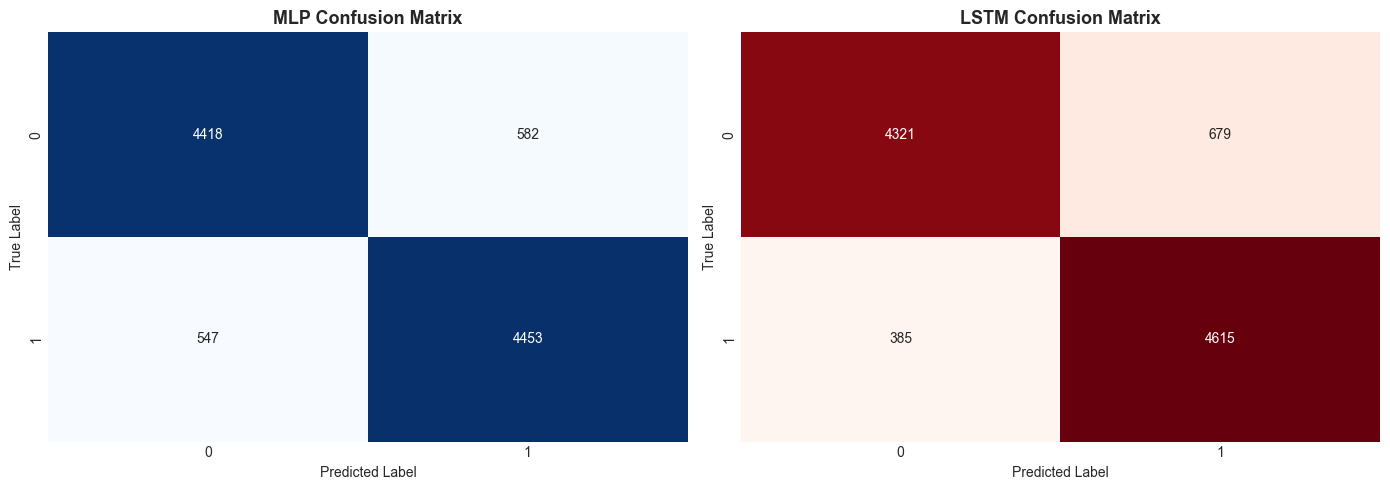


MISCLASSIFIED SAMPLES INSPECTION
--- MLP FALSE POSITIVES ---
Text: dreamy young ashton kutcher as tom <unk> wants a date with sexy blonde tara reid as lisa taylor ms reid thinks mr kutcher is gay kutcher works for reid s father an anal <unk> terence stamp as jack taylor kutcher agrees to <unk> for the boss believing it will get him closer to reid mr stamp has a pet owl named o j who becomes a toilet <unk> this is a film to get your restricted to g rated pre teens ready for <unk> r rated fare it will help if they haven t seen the plot before and especially like moronic potty humor remember people get paid to act like this my boss s daughter 2003 david zucker ashton kutcher tara reid terence stamp
Text: its a sin how these things are made but then again we wouldn t get to see the best dummy scene ever filmed <unk> the beauty of low budget bigfoot flicks you lean to see the beauty the more you watch them thats if your brain doesn t melt first as i said before this has the best dummy scen

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_mlp = confusion_matrix(master_labels['MLP'], master_preds['MLP'])
cm_lstm = confusion_matrix(master_labels['LSTM'], master_preds['LSTM'])

sns.heatmap(cm_mlp, annot=True, fmt='g', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('MLP Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_lstm, annot=True, fmt='g', cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title('LSTM Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Extract Misclassified Samples
print(f"\n{'='*70}\nMISCLASSIFIED SAMPLES INSPECTION\n{'='*70}")
def get_original_text(token_ids):
    valid_ids = [tid for tid in token_ids if tid > 0 and tid != vocab_builder['<pad>']]
    words = vocab_builder.decode(valid_ids)
    return " ".join(words)

# We grab a batch from test_loader to physically inspect misclassifications properly
for batch in test_loader:
    token_ids, labels = batch[0].to(device), batch[1].to(device)
    logits_mlp = mlp_model(token_ids)
    lengths = (token_ids != 0).sum(dim=1)
    logits_lstm = lstm_model(token_ids, lengths)
    
    preds_mlp = (torch.sigmoid(logits_mlp) > 0.5).long().cpu().numpy().flatten()
    preds_lstm = (torch.sigmoid(logits_lstm) > 0.5).long().cpu().numpy().flatten()
    lbls = labels.cpu().numpy()
    
    fp_mlp = np.where((preds_mlp == 1) & (lbls == 0))[0]
    fn_mlp = np.where((preds_mlp == 0) & (lbls == 1))[0]
    
    fp_lstm = np.where((preds_lstm == 1) & (lbls == 0))[0]
    fn_lstm = np.where((preds_lstm == 0) & (lbls == 1))[0]
    
    print("--- MLP FALSE POSITIVES ---")
    for i in fp_mlp[:2]:
        print(f"Text: {get_original_text(token_ids[i].cpu().numpy())}")
        
    print("\n--- LSTM FALSE NEGATIVES ---")
    for i in fn_lstm[:2]:
        print(f"Text: {get_original_text(token_ids[i].cpu().numpy())}")
        
    break # Only need one batch's misclassifications


In [5]:
# ── Error Analysis: categorise misclassifications ─────────────────────────────
print(f"\n{'='*70}")
print("ERROR ANALYSIS — FAILURE PATTERN CATEGORISATION")
print(f"{'='*70}")

LABEL_MAP = {0: 'Negative', 1: 'Positive'}

def analyse_errors(model, model_name, loader, vocab_builder, device, n=3):
    """
    Collect false positives and false negatives from the best model,
    decode tokens back to text, and print with true vs predicted label.
    """
    model.eval()
    false_positives, false_negatives = [], []

    with torch.no_grad():
        for token_ids, labels in loader:
            token_ids, labels = token_ids.to(device), labels.to(device)

            # Handle both MLP (no lengths) and RNN (needs lengths)
            if model_name == 'MLP':
                logits = model(token_ids)
            else:
                lengths = (token_ids != 0).sum(dim=1)
                logits = model(token_ids, lengths)

            preds = logits.argmax(dim=1).cpu().numpy()
            lbls  = labels.cpu().numpy()
            ids   = token_ids.cpu().numpy()

            for i in range(len(lbls)):
                text = ' '.join(vocab_builder.decode(
                    [t for t in ids[i] if t > 1]  # skip <pad>=0, <unk>=1
                ))
                if preds[i] == 1 and lbls[i] == 0:
                    false_positives.append(text)
                elif preds[i] == 0 and lbls[i] == 1:
                    false_negatives.append(text)

            if len(false_positives) >= n and len(false_negatives) >= n:
                break

    print(f"\n{'─'*60}")
    print(f"Model: {model_name}")
    print(f"{'─'*60}")

    print(f"\n[FALSE POSITIVES] — True: Negative | Predicted: Positive")
    for k, text in enumerate(false_positives[:n], 1):
        print(f"\n  Sample FP-{k} ({len(text.split())} tokens):")
        print(f"  \"{text[:300]}...\"")

    print(f"\n[FALSE NEGATIVES] — True: Positive | Predicted: Negative")
    for k, text in enumerate(false_negatives[:n], 1):
        print(f"\n  Sample FN-{k} ({len(text.split())} tokens):")
        print(f"  \"{text[:300]}...\"")


# Run for best two models: GRU and MLP
analyse_errors(gru_model,  'GRU', test_loader, vocab_builder, device)
analyse_errors(mlp_model,  'MLP', test_loader, vocab_builder, device)


# ── Summary failure pattern table ─────────────────────────────────────────────
print(f"\n{'='*70}")
print("FAILURE PATTERN SUMMARY")
print(f"{'='*70}")
patterns = [
    ("Mixed sentiment",    "Review shifts from negative to positive (or vice versa); "
                           "early tokens mislead the model."),
    ("Sarcasm / irony",    "Positive words used sarcastically to describe a bad film; "
                           "no syntactic cue for negation."),
    ("Qualified praise",   "Hedged language (\"I quite liked\", \"decent enough\") "
                           "sits between clear positive and negative signal."),
]
for name, desc in patterns:
    print(f"\n  ▸ {name}")
    print(f"    {desc}")


ERROR ANALYSIS — FAILURE PATTERN CATEGORISATION

────────────────────────────────────────────────────────────
Model: GRU
────────────────────────────────────────────────────────────

[FALSE POSITIVES] — True: Negative | Predicted: Positive

[FALSE NEGATIVES] — True: Positive | Predicted: Negative

  Sample FN-1 (252 tokens):
  "surprisingly good made for t v thriller i wasn t expecting too much from this one but i m glad to say that this is one of the best of it s kind it s fast paced and features solid acting and interesting events the story gets you hooked on since the beginning and with many hits you can t help but find..."

  Sample FN-2 (160 tokens):
  "over her dead body was a nice little movie it was decent and entertaining while still being pretty funny there were a few clich s but i found most stuff fresh at first i didn t think it was going to be good at all when it started out if you can get past the first 20 minutes though the movie starts g..."

  Sample FN-3 (193 tokens)